In [ ]:
# Laboratorio 3 – Conver HSV → RGB
Flujo: imagen RGB → RGB2HSV → HSV2RGB → mostrar canales R, G, B

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [15, 5]

img = cv2.cvtColor(cv2.imread('colores.jpg'), cv2.COLOR_BGR2RGB)

def RGB2HSV(img):
    img = img.astype(np.float32) / 255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img, axis=2)
    maxValue = np.amax(img, axis=2)
    minValue = np.amin(img, axis=2)

    new_img[..., 2] = maxValue  
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i, j] == 0:
                new_img[i, j, 1] = 0
            else:
                new_img[i, j, 1] = (maxValue[i, j] - minValue[i, j]) / maxValue[i, j]

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            delta = maxValue[i, j] - minValue[i, j]
            if delta == 0:
                new_img[i, j, 0] = 0
            elif maxChannel[i, j] == 0:  # R
                new_img[i, j, 0] = 60 * ((img[i, j, 1] - img[i, j, 2]) / delta)
            elif maxChannel[i, j] == 1:  # G
                new_img[i, j, 0] = 120 + 60 * ((img[i, j, 2] - img[i, j, 0]) / delta)
            elif maxChannel[i, j] == 2:  # B
                new_img[i, j, 0] = 240 + 60 * ((img[i, j, 0] - img[i, j, 1]) / delta)

        neg = new_img[..., 0] < 0
        new_img[neg, 0] += 360

    return new_img

hsv_img = RGB2HSV(img)

Conversión RGB → HSV completada. Shape: (626, 626, 3)


In [ ]:
def HSV2RGB(hsv):
    H = hsv[..., 0]
    S = hsv[..., 1]
    V = hsv[..., 2]

    C = V * S
    X = C * (1 - np.abs((H / 60) % 2 - 1))
    m = V - C

    R_ = np.zeros_like(H)
    G_ = np.zeros_like(H)
    B_ = np.zeros_like(H)

    mask0 = (H >= 0)   & (H < 60);  R_[mask0] = C[mask0]; G_[mask0] = X[mask0]
    mask1 = (H >= 60)  & (H < 120); R_[mask1] = X[mask1]; G_[mask1] = C[mask1]
    mask2 = (H >= 120) & (H < 180); G_[mask2] = C[mask2]; B_[mask2] = X[mask2]
    mask3 = (H >= 180) & (H < 240); G_[mask3] = X[mask3]; B_[mask3] = C[mask3]
    mask4 = (H >= 240) & (H < 300); R_[mask4] = X[mask4]; B_[mask4] = C[mask4]
    mask5 = (H >= 300) & (H < 360); R_[mask5] = C[mask5]; B_[mask5] = X[mask5]

    rgb = np.stack([(R_ + m), (G_ + m), (B_ + m)], axis=2)
    return np.clip(rgb * 255, 0, 255).astype(np.uint8)

img_reconstruida = HSV2RGB(hsv_img)

Conversión HSV → RGB completada. Shape: (626, 626, 3)


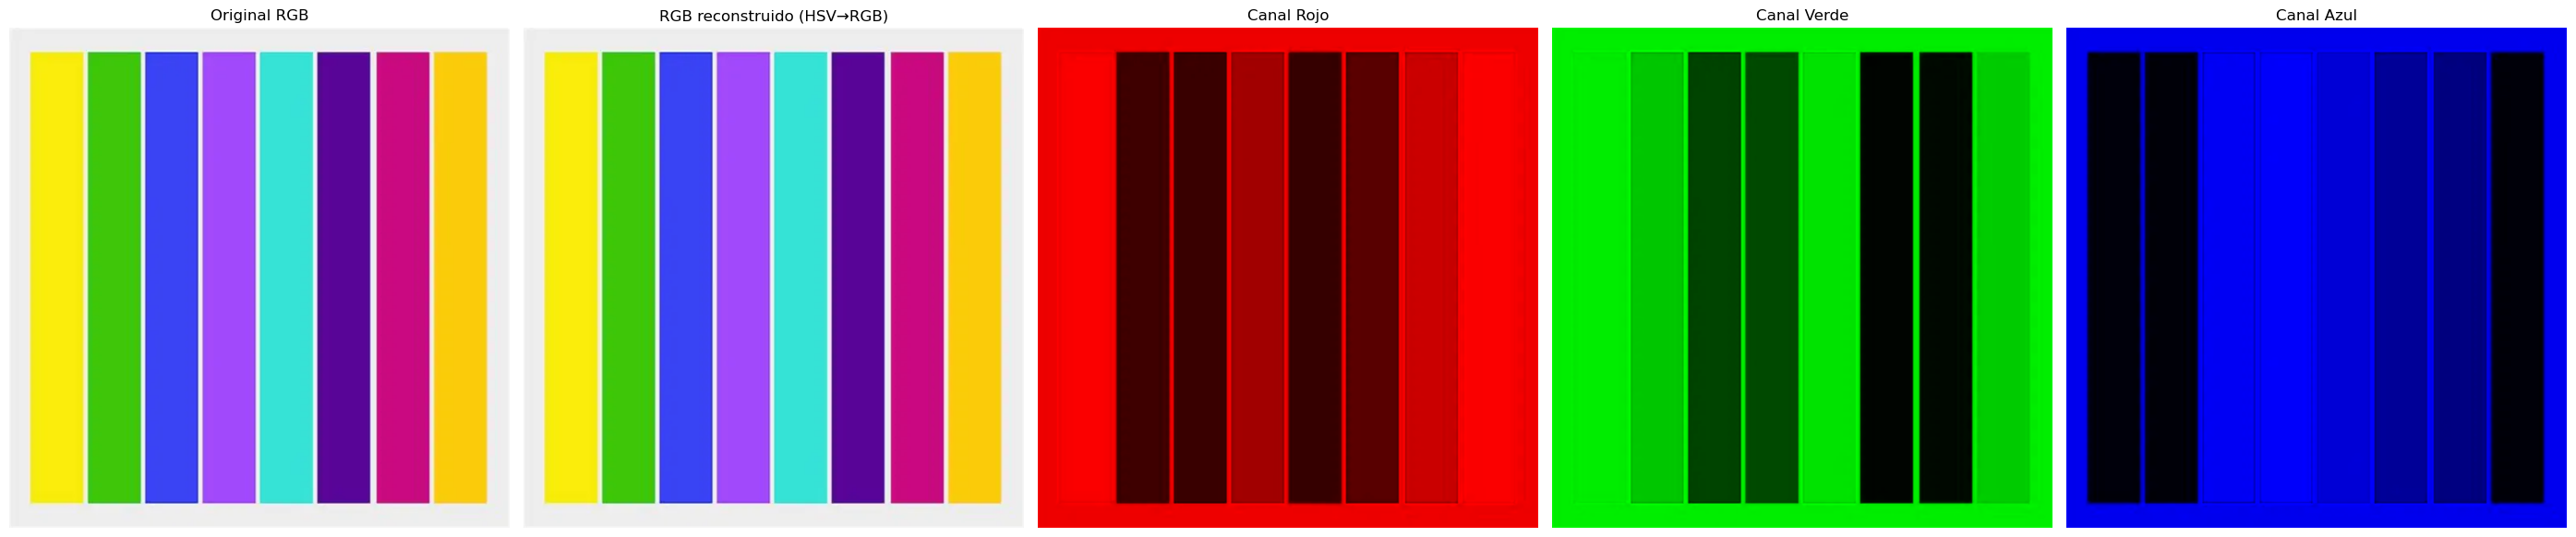

Error máximo entre original y reconstruida: 1 px
Error promedio: 0.2848 px


In [ ]:
# Descomposición por canales con zeros_like
r_img = np.zeros_like(img_reconstruida)
r_img[:, :, 0] = img_reconstruida[:, :, 0]

g_img = np.zeros_like(img_reconstruida)
g_img[:, :, 1] = img_reconstruida[:, :, 1]

b_img = np.zeros_like(img_reconstruida)
b_img[:, :, 2] = img_reconstruida[:, :, 2]

plt.subplot(151)
plt.title('Original')
plt.imshow(img)

plt.subplot(152)
plt.title('HSV -> RGB')
plt.imshow(img_reconstruida)

plt.subplot(153)
plt.title('Canal Rojo')
plt.imshow(r_img)

plt.subplot(154)
plt.title('Canal Verde')
plt.imshow(g_img)

plt.subplot(155)
plt.title('Canal Azul')
plt.imshow(b_img)

plt.show()